In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

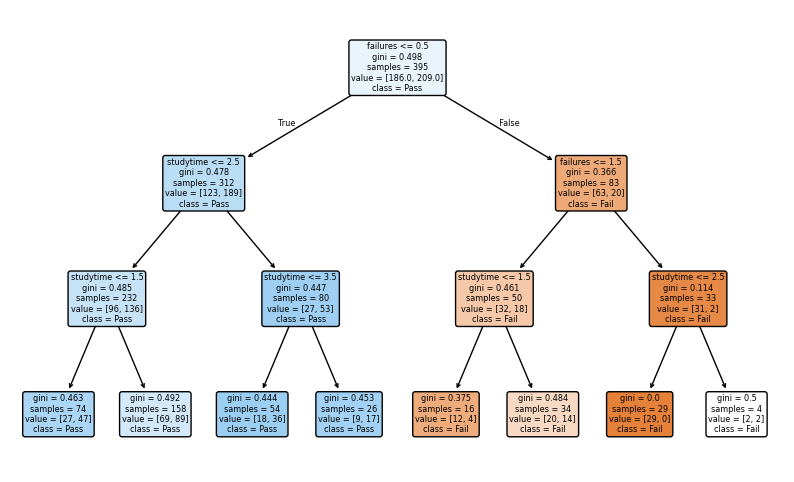

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_log, y_log)

plt.figure(figsize=(10,6))

plot_tree(
    tree,
    feature_names=['studytime', 'failures'],
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True
)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


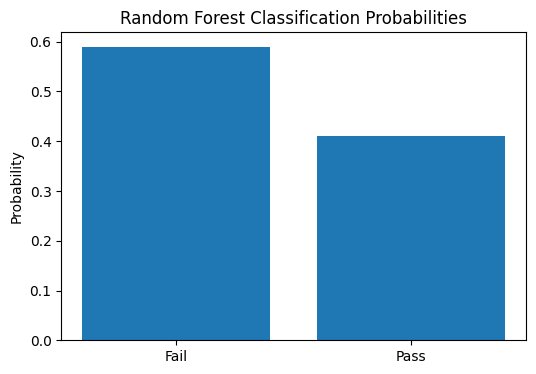

In [17]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42)
rf.fit(X_log, y_log)

prob = rf.predict_proba([[3,1]])[0]

plt.figure(figsize=(6,4))

plt.bar(
    ['Fail', 'Pass'],
    prob
)

plt.ylabel("Probability")
plt.title("Random Forest Classification Probabilities")

plt.show()

Q-table:
[[ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.         -4.39211673  0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]


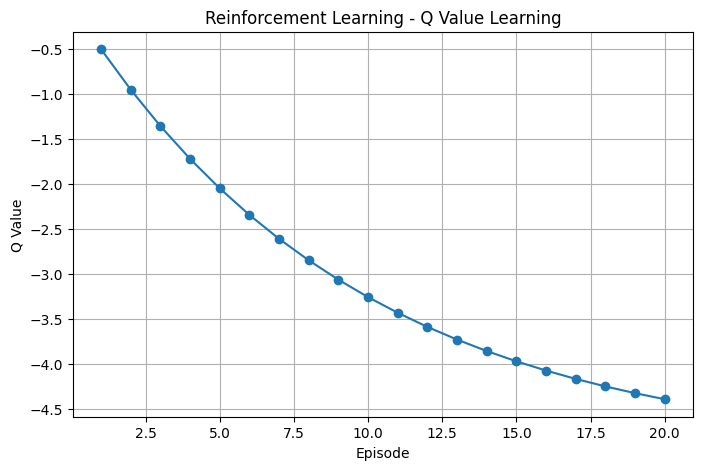

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Q-table
Q = np.zeros((7, 3))

# Sample state
studytime = 3
failures = 1

state = (studytime, failures)

# Reward
if studytime >= 3 and failures == 0:
    reward = 10
else:
    reward = -5

# Store Q-values for graph
q_values = []

# Learning for 20 episodes
for episode in range(20):
    Q[state[0], state[1]] = Q[state[0], state[1]] + 0.1 * (
        reward - Q[state[0], state[1]]
    )

    q_values.append(Q[state[0], state[1]])

print("Q-table:")
print(Q)

# Visualization
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 21),
    q_values,
    marker='o'
)

plt.title("Reinforcement Learning - Q Value Learning")
plt.xlabel("Episode")
plt.ylabel("Q Value")
plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Prediction: [False]


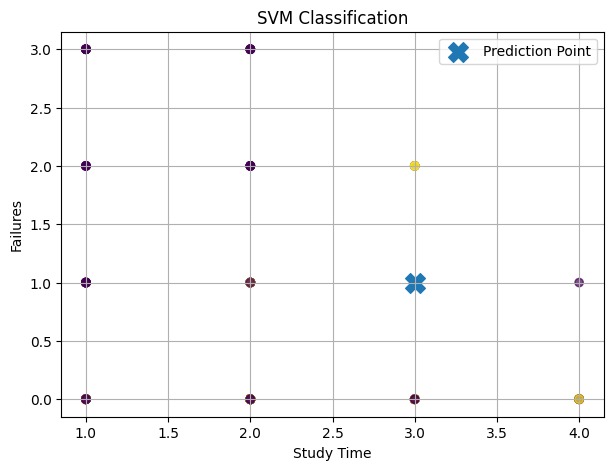

In [19]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt

svm = SVC()
svm.fit(X_log, y_log)

prediction = svm.predict([[3,1]])
print("Prediction:", prediction)

plt.figure(figsize=(7,5))

plt.scatter(
    X_log['studytime'],
    X_log['failures'],
    c=y_log.astype(int),
    alpha=0.7
)

plt.scatter(
    3,
    1,
    marker='X',
    s=200,
    label='Prediction Point'
)

plt.xlabel("Study Time")
plt.ylabel("Failures")
plt.title("SVM Classification")
plt.legend()
plt.grid(True)

plt.show()

[[ 0.12305501]
 [ 0.12305501]
 [-1.26378593]
 [ 1.00978885]
 [ 0.12305501]]


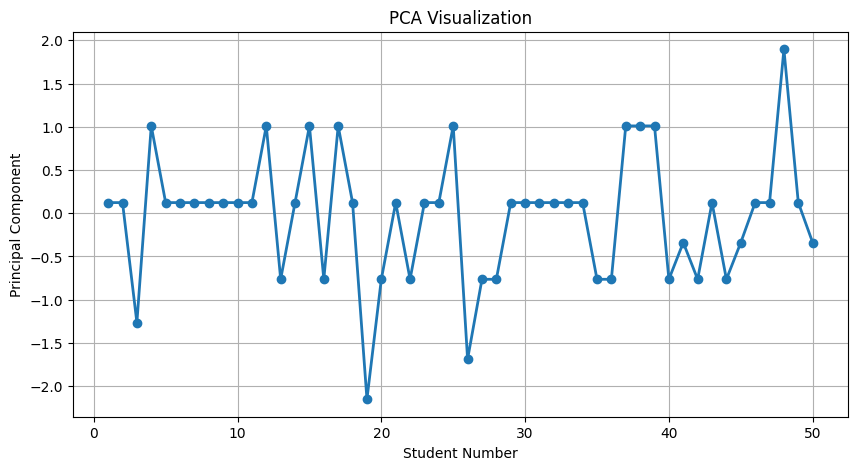

In [22]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=1)
x_pca = pca.fit_transform(X_log)

print(x_pca[:5])

# Take first 50 samples only
pca_values = x_pca[:50].flatten()

plt.figure(figsize=(10,5))

plt.plot(
    range(1, 51),
    pca_values,
    marker='o',
    linewidth=2
)

plt.title("PCA Visualization")
plt.xlabel("Student Number")
plt.ylabel("Principal Component")
plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Prediction: [[1.2856616]]


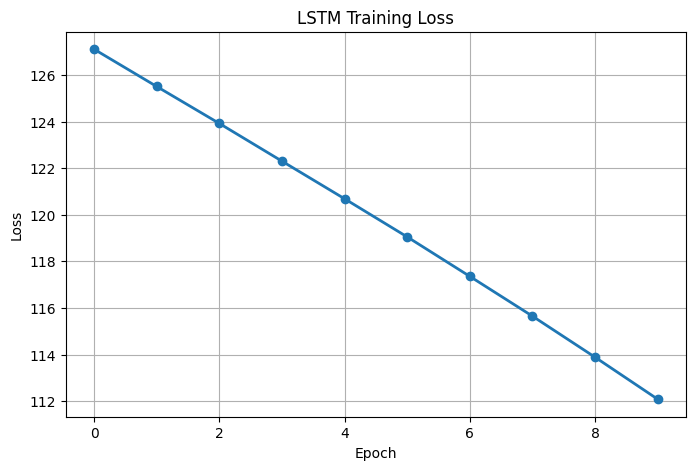

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Data
x = data[['studytime', 'failures']].values
y = data['G3'].values

# Reshape for LSTM
x = x.reshape((x.shape[0], 1, x.shape[1]))

# Model
model = Sequential()
model.add(LSTM(10, input_shape=(1, 2)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(
    x,
    y,
    epochs=10,
    verbose=0
)

# Prediction
prediction = model.predict(np.array([[[3,1]]]))

print("Prediction:", prediction)

# Visualization
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2
)

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Q-Network Prediction: [[-0.08135404]]


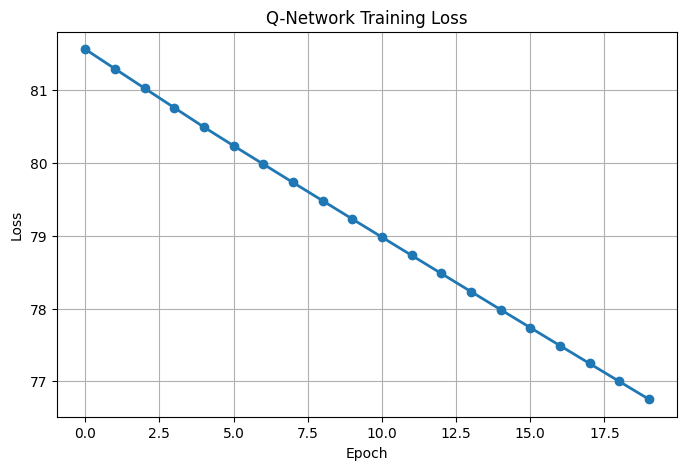

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Input = studytime, failures
X = np.array([
    [1,0],
    [2,0],
    [3,1],
    [4,0],
    [5,1]
])

# Reward values
y = np.array([5, 7, 9, 12, 6])

# Q-Network
model = Sequential()
model.add(Dense(10, input_dim=2, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
history = model.fit(
    X,
    y,
    epochs=20,
    verbose=0
)

# Prediction
prediction = model.predict(np.array([[3,1]]))
print("Q-Network Prediction:", prediction)

# Visualization
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2
)

plt.title("Q-Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()